#  Sales Performance Analysis – Superstore Dataset

## Business Problem

A retail company wants to understand its sales and profitability across different regions and product categories. The goal is to identify opportunities to improve business performance and support data-driven decision-making.



## Objectives

This analysis aims to:

- Explore the structure and quality of the dataset
- Calculate key business performance indicators (KPIs)
- Analyse sales and profit by region
- Identify the top-selling products
- Provide business insights and recommendations based on the findings

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [18]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##  Dataset Overview
The dataset contains retail transaction data including sales, profit, product details, and regional information.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [20]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Initial Observations

- The dataset contains 9,994 transactions.
- There are 21 variables.
- Contains both numerical and categorical features.
- No missing values were detected.
- The dataset is suitable for analysis without additional cleaning.
-

In [21]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


###Key Business KPIs

Total Sales: ~2.3M

Total Profit: ~286K

Insight: Profit margin is relatively low compared to sales volume.This suggests that the company should investigate pricing strategies, discounts and operational costs to improve profitability.

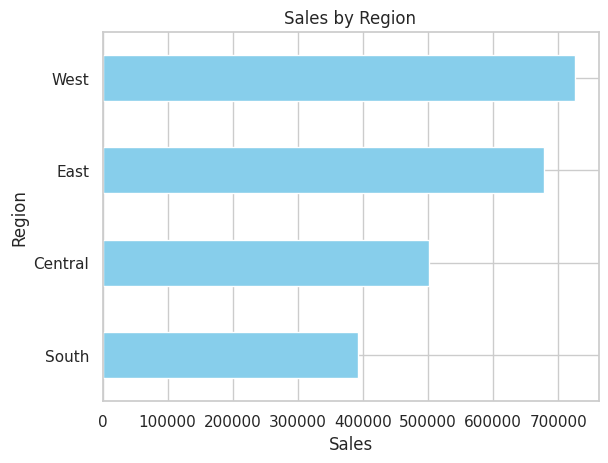

In [22]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

region_sales.plot(kind="barh", color="skyblue")
plt.title("Sales by Region")
plt.xlabel("Sales")
plt.show()
plt.show()

##  Regional Performance Insight
- West region leads in sales
- South region underperforms

 Recommendation: Investigate South region distribution and marketing strategy.

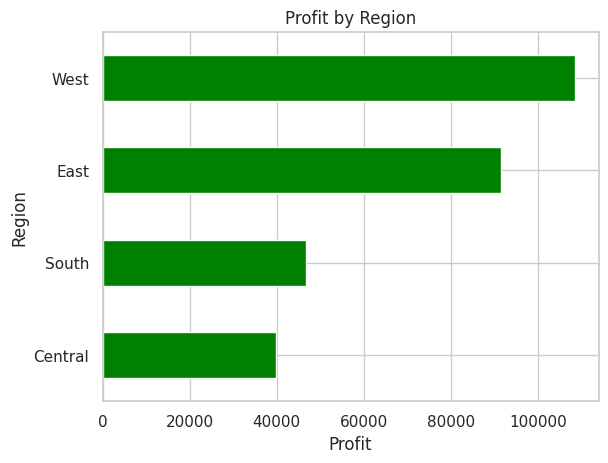

In [23]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

region_profit.plot(kind="barh", color="green")
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.show()

##  Profitability Insight
- Some regions generate high sales but lower profit efficiency
- Indicates possible discounting or cost inefficiencies

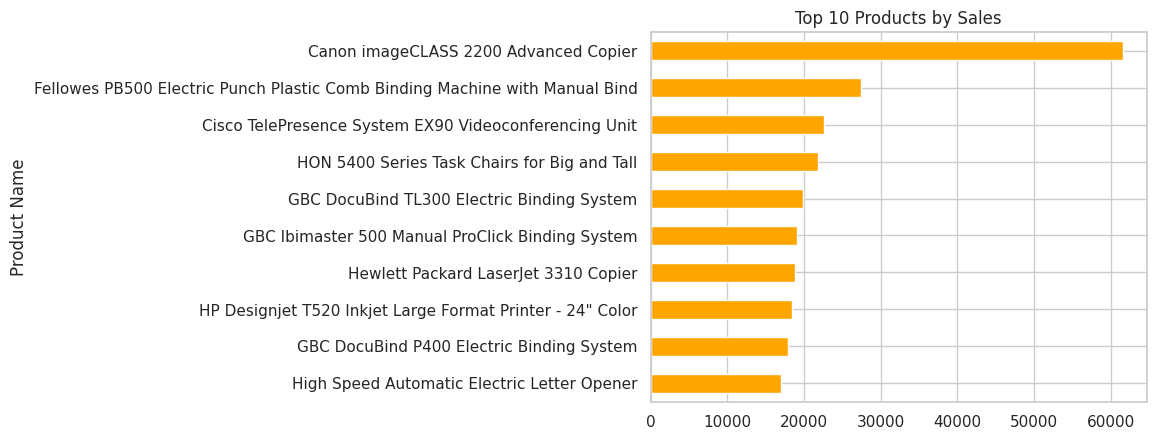

In [24]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh", color="orange")
plt.title("Top 10 Products by Sales")
plt.gca().invert_yaxis()
plt.show()

##  Product Insight
- High revenue comes from office equipment
- Suggests strong B2B (business-to-business) demand

Recommendation: Focus on high-margin products, not just high-sales products.

#  Final Business Insights

1. The West region is the strongest market performer.
2. The South region is underperforming in both sales and profit.
3. The business is driven by high-value office equipment products.
4. Profit margins are relatively low compared to total sales.

#  Recommendations
- Improve strategy in South region
- Focus on improving profit margins (reduce discount dependency)
- Expand high-performing product categories